# Drogued Drifter in Synthetic Flow Profiles

A drogued drifter consists of a surface buoy connected by a rigid pole to a subsurface drogue. The buoy feels surface drag while the drogue is anchored to depth. Under vertical shear, the pole tilts and the buoy drifts at an intermediate speed between the surface current and the drogue-depth current. This notebook demonstrates the `DroguedDrifter` API directly (no Parcels) to show that the steady-state drift velocity lies between surface and drogue-depth velocities.

## Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from drogued_drifters.drifter import DroguedDrifter

In [2]:
U_0 = 2.0              # peak surface current [m/s]
H = 3.0                # e-folding depth [m]
DROGUE_DEPTH = -3.0     # z-up convention     # drogue depth [m]
N_DEPTHS = 50          # number of depth levels

## Define the velocity profile

We prescribe a simple 1D velocity profile with exponential decay with depth and Ekman-like rotation. At each depth z, the current is scaled by exp(-z/H) and rotated by an angle proportional to z.

In [3]:
# Depth array
z_array = np.linspace(0, -10, N_DEPTHS)  # z positive upward

# Exponentially decaying u-profile
u_profile = U_0 * np.exp(z_array / H)  # decays downward (z<0 → exp(z/H) < 1)

# Ekman-like rotation: rotate by -20 degrees per e-folding depth
rotation_deg_per_depth = 20.0  # degrees per e-fold
rotation_angle = np.radians(rotation_deg_per_depth) * z_array / H  # rotates with depth (z<0)

# Rotate the profile: (u, v) = (u0*cos(alpha), u0*sin(alpha))
v_profile = u_profile * np.sin(rotation_angle)
u_profile = u_profile * np.cos(rotation_angle)

## Run drogued drifter model

We create a profile sampler using linear interpolation and then compute the steady-state drift velocity of the drogued drifter. For comparison, we also sample the velocities at the surface (z=0) and at the drogue depth.

In [4]:
# Create interpolation functions for u and v profiles
u_interp = interp1d(z_array, u_profile, kind='linear', bounds_error=False, fill_value='extrapolate')
v_interp = interp1d(z_array, v_profile, kind='linear', bounds_error=False, fill_value='extrapolate')

# Define a sampler: takes depth (scalar or array) and returns (u, v) velocities
def sample_uv(z):
    # Broadcast z to (N,) shape
    z_arr = np.atleast_1d(np.asarray(z, dtype=float))
    u = u_interp(z_arr)
    v = v_interp(z_arr)
    return u, v

# Instantiate drogued drifter and compute steady-state drift
dd = DroguedDrifter()

# get_final_drift_batch expects sample_uv to return (N,) arrays
def sample_uv_single(z):
    z_arr = np.atleast_1d(z)
    u = u_interp(z_arr)
    v = v_interp(z_arr)
    return np.atleast_1d(u), np.atleast_1d(v)

xd_dd, yd_dd, Y_dd, _max_accel = dd.get_final_drift_batch(sample_uv=sample_uv_single)
u_dd = float(xd_dd[0])
v_dd = float(yd_dd[0])

# Sample velocities at surface and drogue depth
u_surf, v_surf = sample_uv(0.0)
u_surf = float(u_surf[0])
v_surf = float(v_surf[0])

u_drogue, v_drogue = sample_uv(DROGUE_DEPTH)
u_drogue = float(u_drogue[0])
v_drogue = float(v_drogue[0])

## Results

In [5]:
# Compute speeds (magnitude of velocity vectors)
speed_surf = np.sqrt(u_surf**2 + v_surf**2)
speed_drogue = np.sqrt(u_drogue**2 + v_drogue**2)
speed_dd = np.sqrt(u_dd**2 + v_dd**2)

print(f"Surface drift speed: {speed_surf:.4f} m/s")
print(f"Drogue-depth drift speed: {speed_drogue:.4f} m/s")
print(f"Drogued drifter drift speed: {speed_dd:.4f} m/s")
print()
print(f"Drogued drifter intermediate behavior:")
assert speed_drogue <= speed_dd <= speed_surf, "DD speed should be between drogue and surface!"
print(f"  {speed_drogue:.4f} <= {speed_dd:.4f} <= {speed_surf:.4f} OK")

Surface drift speed: 2.0000 m/s
Drogue-depth drift speed: 0.7361 m/s
Drogued drifter drift speed: 1.0983 m/s

Drogued drifter intermediate behavior:
  0.7361 <= 1.0983 <= 2.0000 OK


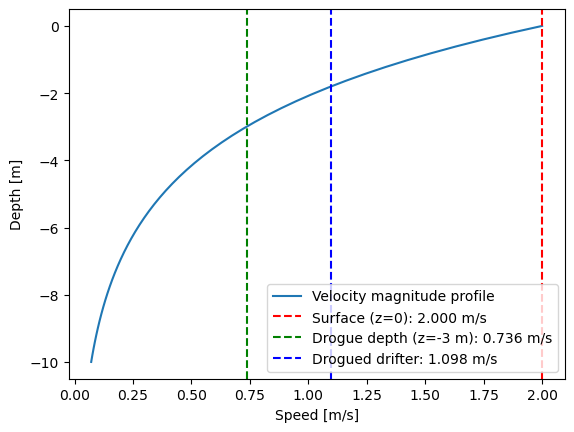

In [6]:
# Plot u-profile vs depth
fig, ax = plt.subplots()

# Compute the magnitude of velocity at each depth
speed_profile = np.sqrt(u_profile**2 + v_profile**2)

ax.plot(speed_profile, z_array, label="Velocity magnitude profile")
ax.axvline(speed_surf, color='red', linestyle='--', label=f"Surface (z=0): {speed_surf:.3f} m/s")
ax.axvline(speed_drogue, color='green', linestyle='--', label=f"Drogue depth (z={DROGUE_DEPTH:.0f} m): {speed_drogue:.3f} m/s")
ax.axvline(speed_dd, color='blue', linestyle='--', label=f"Drogued drifter: {speed_dd:.3f} m/s")

ax.set_xlabel("Speed [m/s]")
ax.set_ylabel("Depth [m]")
ax.legend()
plt.show()

## Sweep over shear strengths

We now vary the surface current speed U_0 and compute the drift velocity for each strength. The drogued drifter drift should always lie between surface and drogue-depth drifts.

In [7]:
u0_values = np.array([0.5, 1.0, 2.0, 4.0])  # m/s
speeds_surf = []
speeds_drogue = []
speeds_dd = []

for U0 in u0_values:
    # Rebuild profiles with new U_0
    u_prof = U0 * np.exp(z_array / H)
    v_prof = u_prof * np.sin(rotation_angle)
    u_prof = u_prof * np.cos(rotation_angle)
    
    # Interpolators
    u_int = interp1d(z_array, u_prof, kind='linear', bounds_error=False, fill_value='extrapolate')
    v_int = interp1d(z_array, v_prof, kind='linear', bounds_error=False, fill_value='extrapolate')
    
    def sample_uv_sweep(z):
        z_arr = np.atleast_1d(z)
        return np.atleast_1d(u_int(z_arr)), np.atleast_1d(v_int(z_arr))
    
    # Compute DD drift
    xd, yd, _Y, _ma = dd.get_final_drift_batch(sample_uv=sample_uv_sweep)
    
    # Sample at surface and drogue depth
    us, vs = sample_uv_sweep(0.0)
    ud, vd = sample_uv_sweep(DROGUE_DEPTH)
    
    speeds_surf.append(np.sqrt(us[0]**2 + vs[0]**2))
    speeds_drogue.append(np.sqrt(ud[0]**2 + vd[0]**2))
    speeds_dd.append(np.sqrt(xd[0]**2 + yd[0]**2))

speeds_surf = np.array(speeds_surf)
speeds_drogue = np.array(speeds_drogue)
speeds_dd = np.array(speeds_dd)

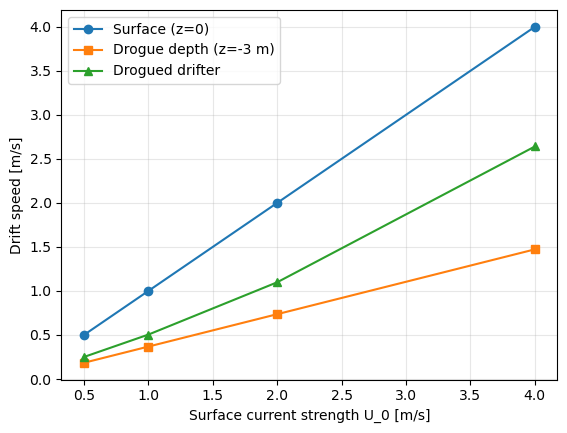

In [8]:
fig, ax = plt.subplots()

ax.plot(u0_values, speeds_surf, 'o-', label='Surface (z=0)')
ax.plot(u0_values, speeds_drogue, 's-', label=f'Drogue depth (z={DROGUE_DEPTH:.0f} m)')
ax.plot(u0_values, speeds_dd, '^-', label='Drogued drifter')

ax.set_xlabel("Surface current strength U_0 [m/s]")
ax.set_ylabel("Drift speed [m/s]")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()